# Завантаження таблиць

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Завантаження файлу
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded)) # ім'я файлу

Saving client_base.xlsx to client_base.xlsx


In [3]:
# Лист customers
df_customers = pd.read_excel(file_name, sheet_name='customers')
df_customers.head()

,user_id,first_name,last_name,email,gender,age,city,acquisition_channel,registration_date
0,U00001,Олесь,Гавриш,oles899@yahoo.com,Male,33,селище Донецьк,Referral,2025-09-19
1,U00002,Віталій,Давиденко,vitaliy.davydenko@ukr.net,Male,25,місто Перемишляни,Instagram,2025-10-20
2,U00003,Єлисей,Архипенко,yelysey748@outlook.com,Male,48,місто Гребінка,Google Ads,2025-10-09
3,U00004,Камілла,Гаєвська,kamilla.hayevska@outlook.com,Female,19,село Славутич,Facebook,2025-08-14
4,U00005,Оксенія,Зінченко,ozinchenko@i.ua,Female,39,селище Устилуг,Email,2025-02-19


In [4]:
# Лист orders
df_orders = pd.read_excel(file_name, sheet_name='orders')
df_orders.head()

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered
3,U00001,2025-09-19,2025-11-23,ORD-251123-00004,112.16,Google Ads,Debit Card,4,5,Delivered
4,U00002,2025-10-20,2025-10-20,ORD-251020-00005,102.52,Google Ads,Credit Card,3,5,Delivered


# Первинна перевірка

In [5]:
df_orders.columns

Index(['user_id', 'registration_date', 'order_date', 'order_id',
       'purchase_amount', 'order_channel', 'payment_method', 'items_count',
       'delivery_days', 'order_status'],
      dtype='object')

In [6]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11904 entries, 0 to 11903
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11904 non-null  object        
 1   registration_date  11904 non-null  datetime64[ns]
 2   order_date         11904 non-null  datetime64[ns]
 3   order_id           11904 non-null  object        
 4   purchase_amount    11904 non-null  float64       
 5   order_channel      11904 non-null  object        
 6   payment_method     11904 non-null  object        
 7   items_count        11904 non-null  int64         
 8   delivery_days      11904 non-null  int64         
 9   order_status       11904 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 930.1+ KB


In [7]:
df_orders.describe()

,registration_date,order_date,purchase_amount,items_count,delivery_days
count,11904,11904,11904.000000,11904.000000,11904.000000
mean,2025-06-04 00:06:31.935483904,2025-07-17 04:43:47.419354880,132.109864,2.643061,4.850806
min,2025-01-01 00:00:00,2025-01-01 00:00:00,20.000000,1.000000,1.000000
25%,2025-03-09 00:00:00,2025-04-29 00:00:00,84.937500,1.000000,3.000000
50%,2025-06-12 00:00:00,2025-07-25 00:00:00,119.320000,2.000000,5.000000
75%,2025-08-11 00:00:00,2025-10-06 00:00:00,163.425000,3.000000,7.000000
max,2025-12-28 00:00:00,2025-12-31 00:00:00,1229.330000,15.000000,10.000000
std,NaN,NaN,67.795580,2.030772,2.493662


In [8]:
df_orders.isna().sum()

,0
user_id,0
registration_date,0
order_date,0
order_id,0
purchase_amount,0
order_channel,0
payment_method,0
items_count,0
delivery_days,0
order_status,0


In [9]:
df_orders['user_id'].duplicated().sum()

np.int64(8904)

In [10]:
df_orders['user_id'].notna().sum()

np.int64(11904)

In [11]:
df_orders.shape

(11904, 10)

In [12]:
df_orders.head()

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered
3,U00001,2025-09-19,2025-11-23,ORD-251123-00004,112.16,Google Ads,Debit Card,4,5,Delivered
4,U00002,2025-10-20,2025-10-20,ORD-251020-00005,102.52,Google Ads,Credit Card,3,5,Delivered


In [13]:
df_orders['user_id'].nunique()

3000

# Створення нових стовпців

In [14]:
# Перетворюємо дати в datetime64
df_orders["registration_date"] = pd.to_datetime(df_orders["registration_date"])
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders.dtypes

,0
user_id,object
registration_date,datetime64[ns]
order_date,datetime64[ns]
order_id,object
purchase_amount,float64
order_channel,object
payment_method,object
items_count,int64
delivery_days,int64
order_status,object


In [15]:
# Cohort month label (YYYY-MM)
df_orders["cohort_month"] = df_orders["registration_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09


In [16]:
df_orders["order_month"] = df_orders["order_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10


In [17]:
# різниця в місяцях між order_date та registration_date
df_orders["month_elapsed"] = (
(df_orders["order_date"].dt.year - df_orders["registration_date"].dt.year) * 12
+ (df_orders["order_date"].dt.month - df_orders["registration_date"].dt.month)
)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month,month_elapsed
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09,0
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10,1
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10,1


# Нові клієнти та динаміка продажів


In [18]:
acq_counts = (df_orders.groupby("cohort_month")["user_id"].nunique().reset_index(name="users"))
acq_counts["cohort_month_dt"] = pd.to_datetime(acq_counts["cohort_month"])
acq_counts = acq_counts.sort_values("cohort_month_dt")
acq_counts

,cohort_month,users,cohort_month_dt
0,2025-01,317,2025-01-01
1,2025-02,291,2025-02-01
2,2025-03,215,2025-03-01
3,2025-04,206,2025-04-01
4,2025-05,221,2025-05-01
5,2025-06,178,2025-06-01
6,2025-07,452,2025-07-01
7,2025-08,317,2025-08-01
8,2025-09,228,2025-09-01
9,2025-10,208,2025-10-01


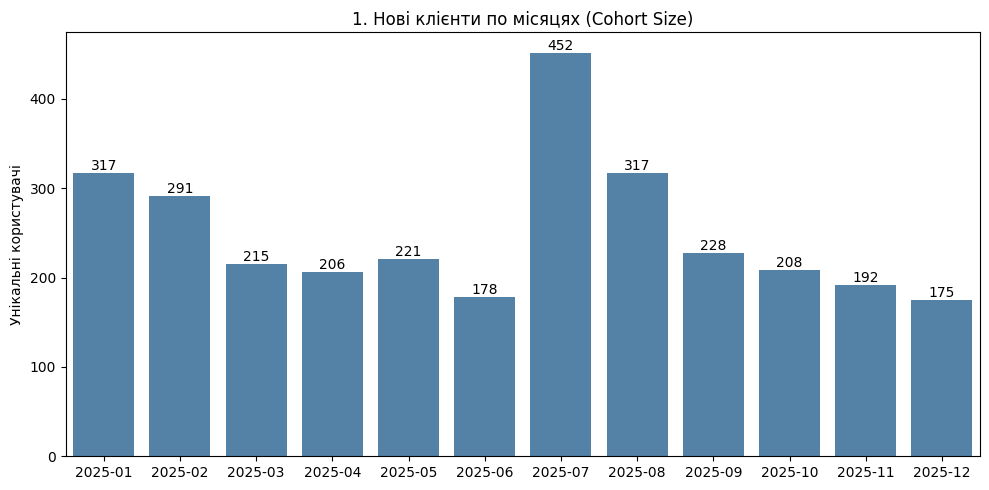

In [20]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=acq_counts, color="steelblue", x="cohort_month", y="users")

plt.title("1. Нові клієнти по місяцях (Cohort Size)")
plt.ylabel("Унікальні користувачі")

for p in ax.patches:
  height = p.get_height()
  ax.annotate(
    f"{height:.0f}",
(p.get_x() + p.get_width() / 2, height),
ha="center", va="bottom"
)
plt.xlabel("")
plt.tight_layout()
plt.show()

In [21]:
# Revenue та кількість замовлень
monthly = (df_orders.groupby("order_month").agg(orders=("order_id","count"), # кількість замовлень
revenue=("purchase_amount",
"sum")).reset_index() # сума доходу
)
monthly = monthly.sort_values("order_month")
monthly

,order_month,orders,revenue
0,2025-01,554,71546.12
1,2025-02,701,95787.41
2,2025-03,858,114871.56
3,2025-04,899,116906.88
4,2025-05,953,126211.02
5,2025-06,912,119791.15
6,2025-07,1299,176556.40
7,2025-08,1409,179603.16
8,2025-09,1128,150446.59
9,2025-10,1236,161706.69


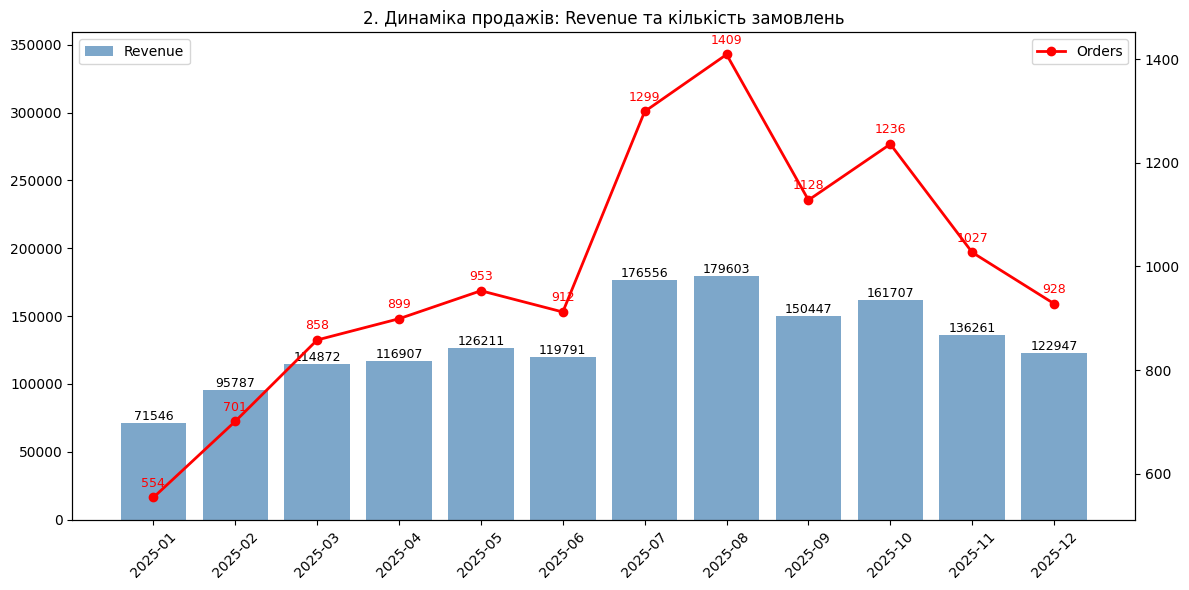

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 6))
# Стовпчики: revenue
ax1.bar(monthly["order_month"], monthly["revenue"], color="steelblue", alpha=0.7, label="Revenue")
ax1.set_ylim(0, monthly["revenue"].max() * 2) # Розтягуємо вісь revenue вдвічі
ax1.tick_params(axis="x", rotation=45)# Підписи на стовпчиках
for bar in ax1.patches:
  ax1.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)
ax2 = ax1.twinx() # Лінія: кількість замовлень (друга вісь)
ax2.plot(monthly["order_month"],
         monthly["orders"],
         color="red",
         marker="o", linewidth=2, label="Orders")
for x, y in zip (monthly["order_month"], monthly["orders"]):
           ax2.text(x, y + 15,
           f"{y:.0f}",
           color="red",
           ha="center", va="bottom", fontsize=9)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("2. Динаміка продажів: Revenue та кількість замовлень")
plt.tight_layout()
plt.show()

# Повернення клієнтів та Retention

In [24]:
# Кількість унікальних клієнтів за когортами і періодами
retention_counts = (
df_orders
.groupby(["cohort_month", "month_elapsed"])["user_id"]
.nunique()
.reset_index(name="users")
)
retention_counts

,cohort_month,month_elapsed,users
0,2025-01,0,317
1,2025-01,1,160
2,2025-01,2,137
3,2025-01,3,119
4,2025-01,4,75
...,...,...,...
72,2025-10,1,113
73,2025-10,2,94
74,2025-11,0,192
75,2025-11,1,95


In [25]:
# Pivot-таблиця
retention_pivot = retention_counts.pivot_table(index="cohort_month", columns="month_elapsed", values="users")
retention_pivot

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,317.0,160.0,137.0,119.0,75.0,52.0,27.0,18.0,6.0,4.0,1.0
2025-02,291.0,170.0,120.0,100.0,72.0,38.0,26.0,14.0,6.0,5.0,2.0
2025-03,215.0,112.0,96.0,66.0,40.0,24.0,18.0,9.0,5.0,3.0,NaN
2025-04,206.0,119.0,96.0,77.0,55.0,26.0,17.0,7.0,3.0,NaN,NaN
2025-05,221.0,122.0,97.0,74.0,48.0,29.0,25.0,13.0,NaN,NaN,NaN
2025-06,178.0,95.0,87.0,54.0,42.0,27.0,16.0,NaN,NaN,NaN,NaN
2025-07,452.0,248.0,178.0,174.0,113.0,59.0,NaN,NaN,NaN,NaN,NaN
2025-08,317.0,155.0,151.0,99.0,75.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,228.0,138.0,98.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


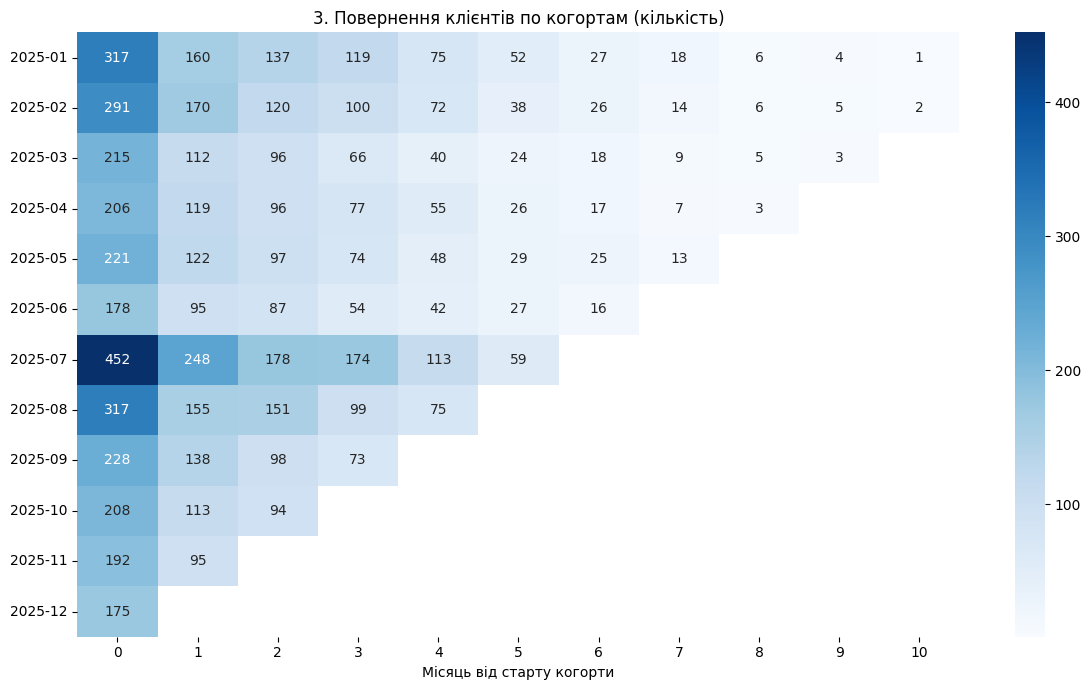

In [26]:
# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pivot, annot=True, fmt="g", cmap="Blues")
plt.title("3. Повернення клієнтів по когортам (кількість)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [27]:
# Розмір когорти (кількість клієнтів у місяць 0)
cohort_size = (df_orders[df_orders["month_elapsed"] == 0].groupby("cohort_month")["user_id"].nunique() )
cohort_size

,user_id
cohort_month,
2025-01,317
2025-02,291
2025-03,215
2025-04,206
2025-05,221
2025-06,178
2025-07,452
2025-08,317
2025-09,228


In [28]:
# Retention rate у відсотках
retention_pct = retention_pivot.div(cohort_size, axis=0) * 100
retention_pct

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,100.0,50.473186,43.217666,37.539432,23.659306,16.403785,8.517350,5.678233,1.892744,1.261830,0.315457
2025-02,100.0,58.419244,41.237113,34.364261,24.742268,13.058419,8.934708,4.810997,2.061856,1.718213,0.687285
2025-03,100.0,52.093023,44.651163,30.697674,18.604651,11.162791,8.372093,4.186047,2.325581,1.395349,NaN
2025-04,100.0,57.766990,46.601942,37.378641,26.699029,12.621359,8.252427,3.398058,1.456311,NaN,NaN
2025-05,100.0,55.203620,43.891403,33.484163,21.719457,13.122172,11.312217,5.882353,NaN,NaN,NaN
2025-06,100.0,53.370787,48.876404,30.337079,23.595506,15.168539,8.988764,NaN,NaN,NaN,NaN
2025-07,100.0,54.867257,39.380531,38.495575,25.000000,13.053097,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,48.895899,47.634069,31.230284,23.659306,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,60.526316,42.982456,32.017544,NaN,NaN,NaN,NaN,NaN,NaN,NaN


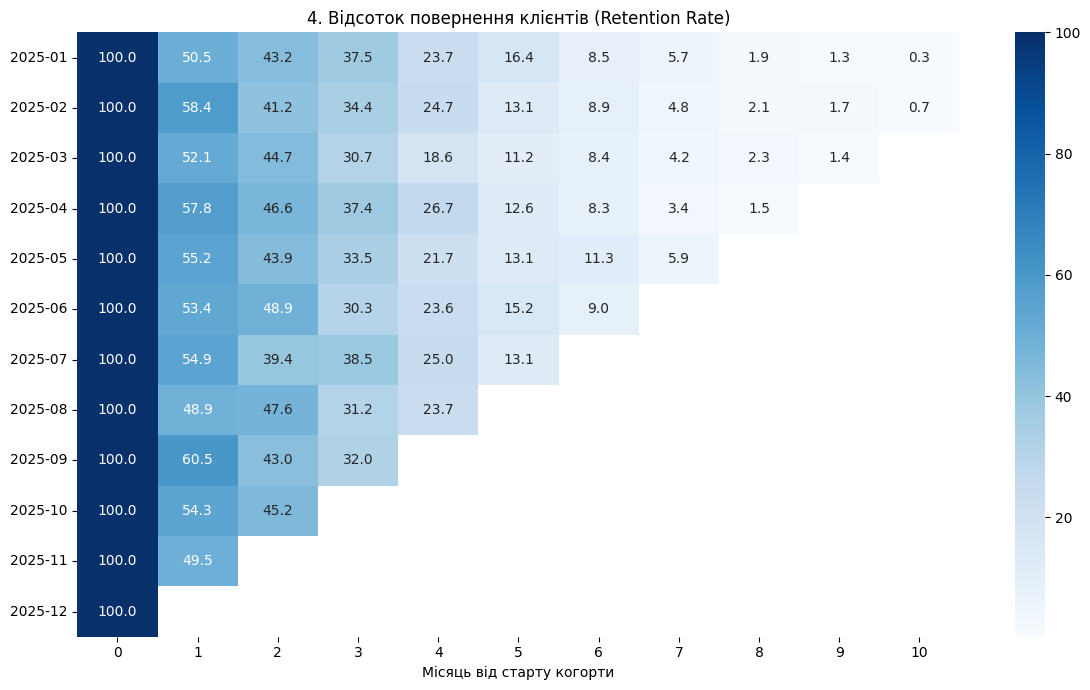

In [29]:
# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("4. Відсоток повернення клієнтів (Retention Rate)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Revenue та Cumulative Revenue

In [30]:
# Revenue за когортами і періодами
rev_by_cohort = (
df_orders
.groupby(["cohort_month", "month_elapsed"])["purchase_amount"]
.sum()
.reset_index(name="revenue")
.sort_values(["cohort_month", "month_elapsed"])
)
rev_by_cohort

,cohort_month,month_elapsed,revenue
0,2025-01,0,71546.12
1,2025-01,1,31832.39
2,2025-01,2,27705.47
3,2025-01,3,24954.17
4,2025-01,4,15223.97
...,...,...,...
72,2025-10,1,22806.10
73,2025-10,2,17540.53
74,2025-11,0,40640.58
75,2025-11,1,19883.19


In [31]:
# Pivot для Heatmap revenue
rev_matrix = rev_by_cohort.pivot_table(index="cohort_month", columns="month_elapsed", values="revenue")
rev_matrix

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,71546.12,31832.39,27705.47,24954.17,15223.97,8868.43,4736.33,3716.92,853.40,923.08,50.94
2025-02,63955.02,37557.24,24691.05,17973.29,14228.49,6796.43,4219.57,2160.17,930.94,710.36,301.95
2025-03,49608.85,24615.18,20518.00,12760.99,8196.12,5627.39,3062.91,2264.72,1111.30,436.65,NaN
2025-04,42646.48,23611.48,17374.69,15723.91,9962.10,3880.05,3682.64,1297.29,239.61,NaN,NaN
2025-05,48884.28,25676.03,20206.76,13381.81,11059.78,5924.88,5347.43,1449.82,NaN,NaN,NaN
2025-06,40882.52,19849.40,15117.09,11988.96,9640.96,4436.14,1883.39,NaN,NaN,NaN,NaN
2025-07,101047.45,55519.53,37181.92,34786.91,19805.92,11440.99,NaN,NaN,NaN,NaN,NaN
2025-08,72058.75,32199.83,30226.69,19100.03,14847.21,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,48059.57,30356.51,20955.33,14872.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


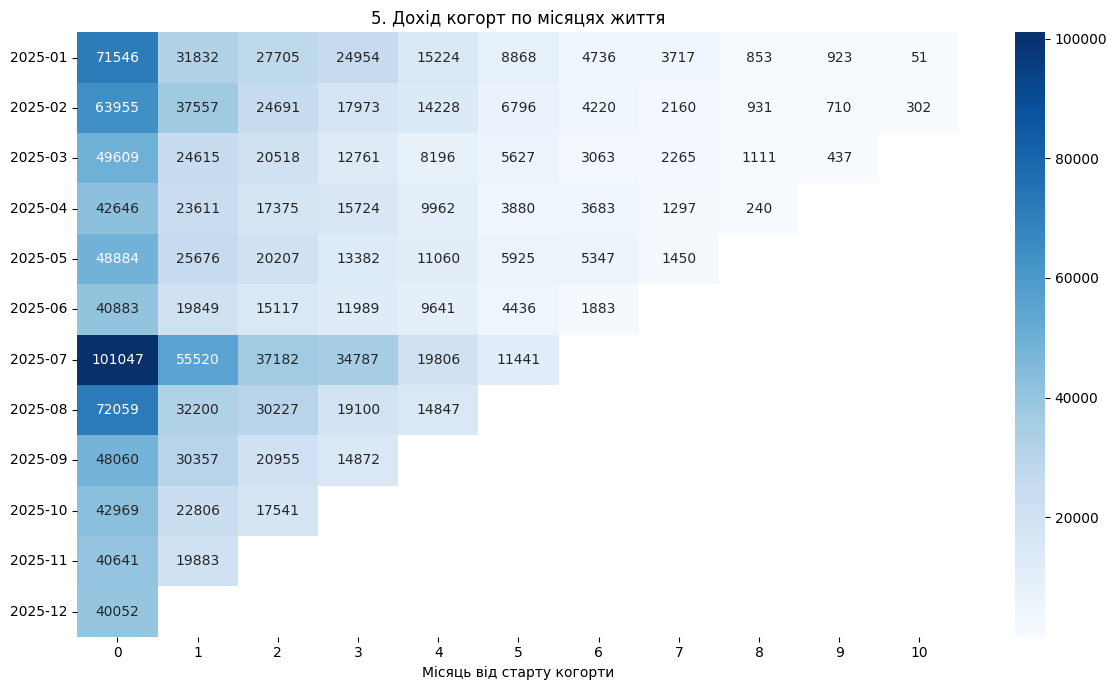

In [32]:
# Heatmap
# Дохід когорт по місяцях життя
plt.figure(figsize=(12, 7))
sns.heatmap(rev_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("5. Дохід когорт по місяцях життя")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [33]:
# Накопичувальний revenue
rev_by_cohort["revenue_cum"] = rev_by_cohort.groupby("cohort_month")["revenue"].cumsum()
rev_by_cohort

,cohort_month,month_elapsed,revenue,revenue_cum
0,2025-01,0,71546.12,71546.12
1,2025-01,1,31832.39,103378.51
2,2025-01,2,27705.47,131083.98
3,2025-01,3,24954.17,156038.15
4,2025-01,4,15223.97,171262.12
...,...,...,...,...
72,2025-10,1,22806.10,65775.46
73,2025-10,2,17540.53,83315.99
74,2025-11,0,40640.58,40640.58
75,2025-11,1,19883.19,60523.77


In [34]:
rev_cum_matrix = rev_by_cohort.pivot_table(index="cohort_month", columns="month_elapsed", values="revenue_cum")
rev_cum_matrix

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,71546.12,103378.51,131083.98,156038.15,171262.12,180130.55,184866.88,188583.80,189437.20,190360.28,190411.22
2025-02,63955.02,101512.26,126203.31,144176.60,158405.09,165201.52,169421.09,171581.26,172512.20,173222.56,173524.51
2025-03,49608.85,74224.03,94742.03,107503.02,115699.14,121326.53,124389.44,126654.16,127765.46,128202.11,NaN
2025-04,42646.48,66257.96,83632.65,99356.56,109318.66,113198.71,116881.35,118178.64,118418.25,NaN,NaN
2025-05,48884.28,74560.31,94767.07,108148.88,119208.66,125133.54,130480.97,131930.79,NaN,NaN,NaN
2025-06,40882.52,60731.92,75849.01,87837.97,97478.93,101915.07,103798.46,NaN,NaN,NaN,NaN
2025-07,101047.45,156566.98,193748.90,228535.81,248341.73,259782.72,NaN,NaN,NaN,NaN,NaN
2025-08,72058.75,104258.58,134485.27,153585.30,168432.51,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,48059.57,78416.08,99371.41,114243.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN


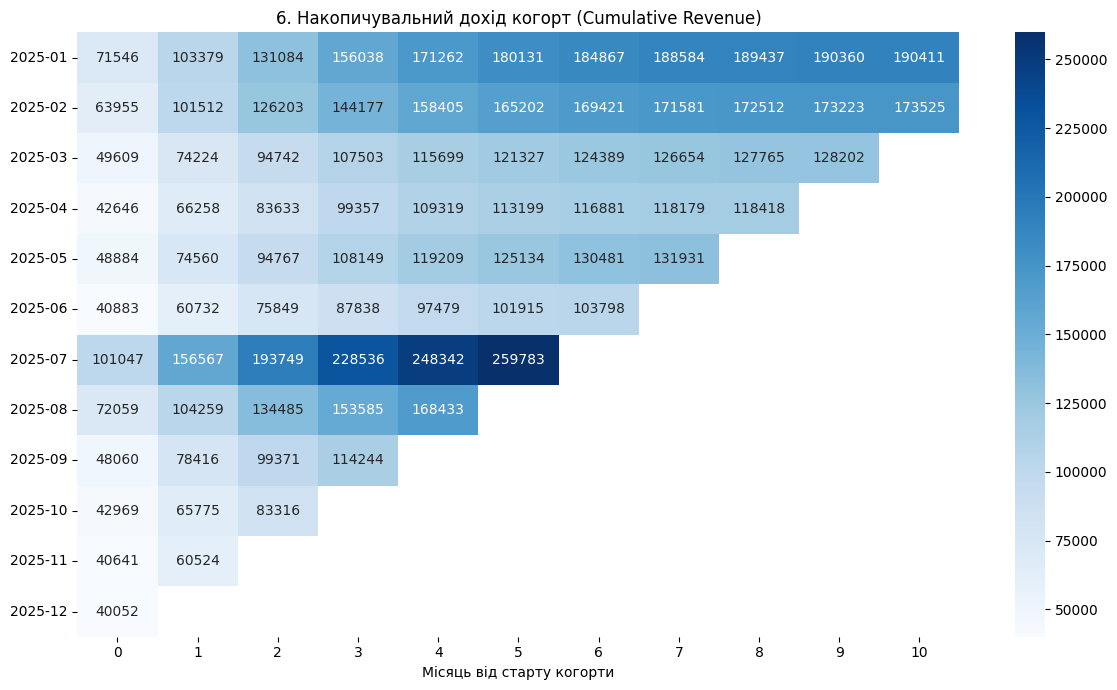

In [35]:
# Heatmap
# Накопичувальний дохід когорт (Cumulative Revenue)
plt.figure(figsize=(12, 7))
sns.heatmap(rev_cum_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("6. Накопичувальний дохід когорт (Cumulative Revenue)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Аналіз канали залучення

In [36]:
# Створення табл для аналізу каналів залучення
summary=df_orders.groupby("order_channel").agg(
    users=("user_id", "nunique"),
    orders=("order_id", "count"),
    revenue=("purchase_amount", "sum")
).reset_index()
print(summary)

  order_channel  users  orders    revenue
0         Email   1354    1765  194885.13
1      Facebook   1601    2340  291480.15
2    Google Ads   1596    2215  357762.66
3     Instagram   1747    2582  345552.96
4      Referral   1353    1794  253862.03
5       Unknown    986    1208  129092.89


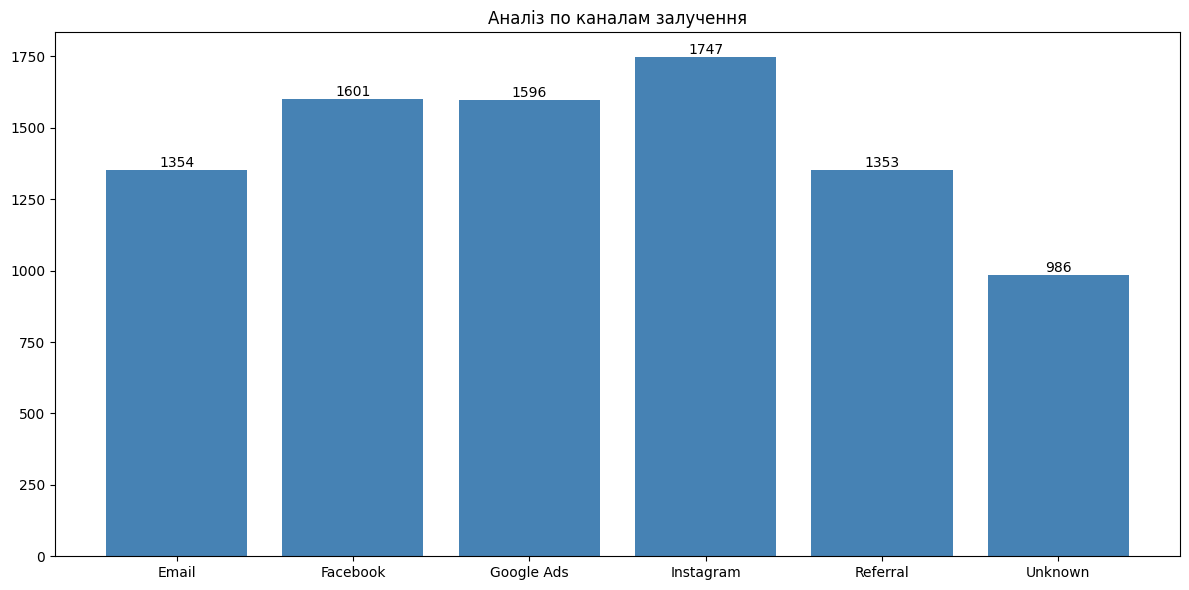

In [37]:
fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(summary["order_channel"],
               summary["users"],
               color="steelblue",
               label="Кількість клієнтів")

# Підписи на стовпчиках
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.0f}",
             ha="center",
             va="bottom")
plt.title("Аналіз по каналам залучення")
plt.tight_layout()
plt.show()

# Висновки

In [ ]:
#Проведений когортний аналіз показує, що найбільша когорта з 452 залученими користувачами була
#у липні 2025р. Retention (повернення) цих користувачів у перший місяць після їх першої покупки
#складає 54.9%. Аналіз користувачів по каналам залучення показує, що найбільше - 1747 користувачів
#було залучено через Instagram.
